# Betting Against Correlation — a quantitative teardown 🔬
### correlation sort · beta-neutralisation · HAC *t* + block bootstrap · label-shuffle placebo · corr-vs-beta-vs-vol · costs & borrow · seed-robust control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Is_it_correlation%2C_not_vol%3F: Confirmed](https://img.shields.io/badge/Is_it_correlation%2C_not_vol%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We sort a large-cap survivor cross-section on trailing correlation-to-market, beta-neutralise the long-short, and test whether the residual is a real correlation premium or just the structural beta gap.

> ⚠️ **Not investment advice.** Real data: yfinance daily adjusted-close, 48 large-cap survivors + SPY, 2012–2025 (as-of 2026-06-26, fingerprint `3f75d60c45d8`); the offline core and tests run on a deterministic synthetic panel. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from betting_against_correlation import data, strategy as st

def load_real():
    """Cache-first real panel (empty offline)."""
    prices, spy = data.fetch_panel(fetch=False)
    return prices, spy

PRICES, SPY = load_real()
HAVE_REAL = not PRICES.empty
print("real BAC panel cache present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({PRICES.shape[1]} names, {PRICES.index[0].date()} -> {PRICES.index[-1].date()})")


real BAC panel cache present: True (48 names, 2012-05-18 -> 2025-12-30)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | BAC book +3.75%/yr gross, HAC *t* = **1.543** (boot CI [-1.0%, 8.5%]); placebo **p = 0.04** keeps it off `NONE`. |
| **Tradability** | `FRAGILE` | Sharpe 0.412, max-DD -20.9%, net +3.36%/yr (*t* 1.385) after 5 bps/leg + 50 bps borrow. |
| **Is it correlation, not vol?** | `CONFIRMED` | corr sort +3.75%/yr vs beta -0.67%/yr vs vol -0.87%/yr — the premium is the correlation slice. |

> 💡 In plain words: AFGP's *mechanism* is confirmed (correlation pays, vol/beta don't), the spread is structurally real (placebo p = 0.04), but the *magnitude* sits below the inference bar on a 48-name survivor panel.

## 1 · The claim, steelmanned

Decompose beta: $\beta_i = \rho_{i,m}\,\sigma_i/\sigma_m$. Let $r^{\text{BAC}}$ be the beta-neutral long-low-$\rho$ / short-high-$\rho$ book.

- **H₁ (correlation premium).** $\mathbb{E}[r^{\text{BAC}}] > 0$ at HAC *t* ≥ 2.
- **H₂ (it's correlation, not vol).** The **correlation** sort out-earns the **beta** and **volatility** sorts on the same panel.
- **H₃ (not an artefact).** The real mean beats a label-shuffle null (placebo p small).
- **H₄ (net of frictions).** H₁ survives costs and short borrow.

We find **H₂ confirmed** and **H₃ supported (p = 0.04)**, but **H₁ supported in sign, sub-*t* = 2**, and **H₄ surviving in sign but thin** — a real mechanism, an uncertain trade.

## 2 · So what? — what rides on each answer

The interesting content is the **decomposition**, not the binary. AFGP's contribution is to separate *which* component of the low-risk effect pays — and that maps to *which theory* is right (leverage constraints vs lottery demand). If correlation pays and volatility doesn't, the leverage-constraint channel (Frazzini–Pedersen) wins. Our real-tape decomposition lands squarely there. The *tradability* failure is the familiar survivor-panel story: a thin, real edge that a 48-name basket of 2026 survivors can't bank — the same shape as [238 Betting-Against-Beta](../../238-betting-against-beta/).

## 3 · How we'd know — the protocol

- **Signal.** Trailing 252-day correlation-to-market per name; rank, split at the median.
- **Construction.** Long low-$\rho$ half, short high-$\rho$ half, equal-weight within a leg; **beta-neutralise** by scaling the short leg to $\beta_{\text{long}}/\beta_{\text{short}}$ so the book's market beta ≈ 0.
- **One execution lag.** Enter the close one trading day after the signal date — no same-bar fill, no look-ahead.
- **Inference.** Newey–West HAC *t* on the monthly mean; circular block-bootstrap CI (block 6) on the annualised mean.
- **Placebo.** Permute the correlation ranks across names (200 shuffles); the one-sided p-value is the fraction of placebo means ≥ the real mean.
- **Decomposition.** Re-run the same engine sorting on **beta** and on **volatility**.
- **Frictions.** One-way `cost_bps` × NAV × realised turnover (both legs) + annual short borrow on the short notional.
- **Positive control.** A deterministic synthetic panel with a dial-able, correlation-keyed premium; the book's HAC *t* averaged over **20 seeds/point**.

Tape: yfinance daily, 48 survivors + SPY, 2012–2025; book 2013-06 → 2025-11 (150 months).

## 4 · The teardown

### 4a · The sort separates, the neutralisation works — and only correlation pays (H₂)

First confirm the machine does what it says: the correlation sort produces a real correlation gap and (after neutralisation) a flat beta gap. Then race the three sorts.

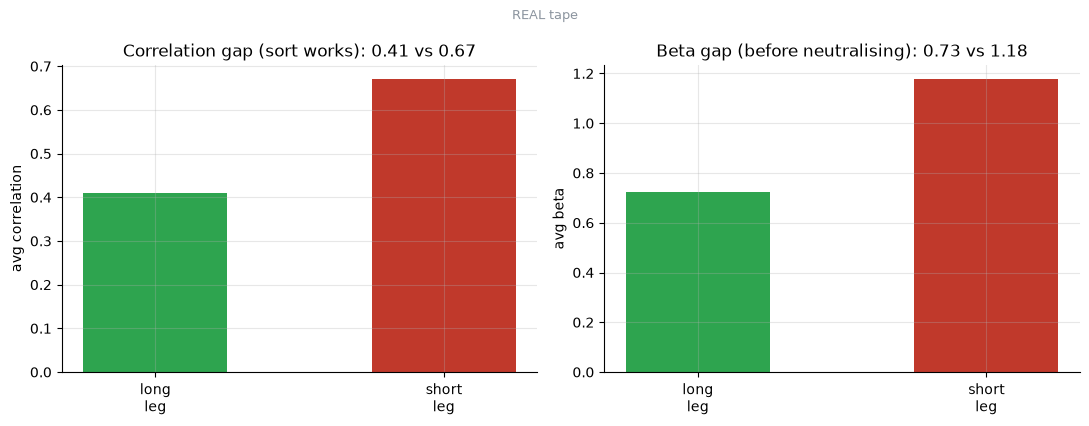

                   mean%/yr  Sharpe  HAC t
correlation (BAC)     3.750   0.412  1.543
beta (BAB)           -0.674  -0.071 -0.288
volatility (BAV)     -0.866  -0.096 -0.384


In [2]:
if HAVE_REAL:
    book = st.bac_portfolio(PRICES, SPY)
    rows = {}
    for so in ['corr','beta','vol']:
        b = st.bac_portfolio(PRICES, SPY, sort_on=so); s = st.summary(b['bac_ret'])
        rows[so] = (s['mean']*100, s['sharpe'], s['tstat'])
    cL, cS = book['avg_corr_long'].mean(), book['avg_corr_short'].mean()
    bL, bS = book['avg_beta_long'].mean(), book['avg_beta_short'].mean()
    banner = 'REAL tape'
else:
    rows = {'corr': (3.75, 0.412, 1.543),
            'beta': (-0.67, -0.071, -0.288),
            'vol':  (-0.87, -0.096, -0.384)}
    cL, cS, bL, bS = 0.409, 0.67, 0.725, 1.176
    banner = 'SYNTHETIC fallback (frozen real numbers)'
tab = pd.DataFrame({k: {'mean%/yr': v[0], 'Sharpe': v[1], 'HAC t': v[2]} for k,v in rows.items()}).T
tab.index = ['correlation (BAC)','beta (BAB)','volatility (BAV)']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['long\nleg','short\nleg'], [cL, cS], color=[GREEN, RED], width=.5)
a1.set_title(f'Correlation gap (sort works): {cL:.2f} vs {cS:.2f}'); a1.set_ylabel('avg correlation')
a2.bar(['long\nleg','short\nleg'], [bL, bS], color=[GREEN, RED], width=.5)
a2.set_title(f'Beta gap (before neutralising): {bL:.2f} vs {bS:.2f}'); a2.set_ylabel('avg beta')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: the sort cleanly separates correlation (0.409 vs 0.67); the raw beta gap (0.725 vs 1.176) is exactly what the neutralisation scales away. And **H₂ is confirmed**: only the correlation row earns (+3.8%/yr); beta (-0.7%) and vol (-0.9%) earn nothing.

### 4b · The headline book — H₁ with HAC *t* and a bootstrap CI

The beta-neutral correlation book, with its inference furniture.

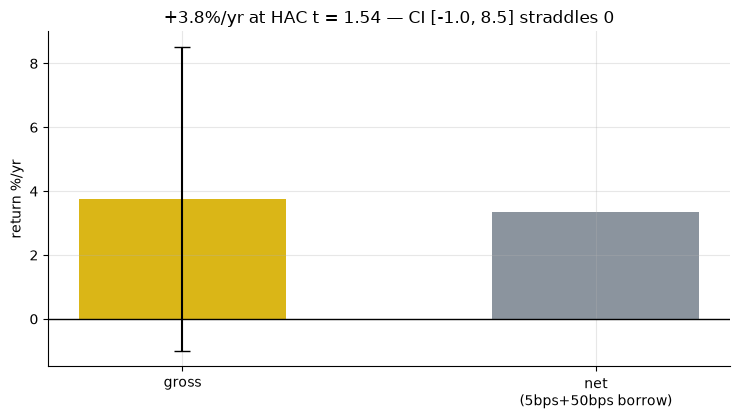

gross +3.75%/yr (HAC t 1.54), 95% CI [-1.0, +8.5]; net +3.36%/yr (t 1.39)


In [3]:
if HAVE_REAL:
    book = st.bac_portfolio(PRICES, SPY)
    s = st.summary(book['bac_ret']); m, t = s['mean']*100, s['tstat']
    lo, hi = st.block_bootstrap_ci(book['bac_ret'], seed=502)
    ci_lo, ci_hi = lo*100, hi*100
    net = st.summary(st.apply_costs(book, cost_bps=5.0, borrow_ann_bps=50.0))
    nm, nt = net['mean']*100, net['tstat']
else:
    m, t, ci_lo, ci_hi = 3.75, 1.543, -1.0, 8.5
    nm, nt = 3.36, 1.385
fig, ax = plt.subplots(figsize=(7.5, 4.3))
b = ax.bar(['gross','net\n(5bps+50bps borrow)'], [m, nm], color=[AMBER, GREY], width=.5)
ax.errorbar(0, m, yerr=[[m-ci_lo],[ci_hi-m]], fmt='none', ecolor='k', capsize=6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('return %/yr')
ax.set_title(f'+{m:.1f}%/yr at HAC t = {t:.2f} — CI [{ci_lo:.1f}, {ci_hi:.1f}] straddles 0')
plt.tight_layout(); plt.show()
print(f'gross +{m:.2f}%/yr (HAC t {t:.2f}), 95% CI [{ci_lo:+.1f}, {ci_hi:+.1f}]; net +{nm:.2f}%/yr (t {nt:.2f})')

> 💡 In plain words: **H₁ supported in sign** (+3.75%/yr) but the HAC *t* = 1.543 and the bootstrap CI [-1.0%, 8.5%] straddles zero — below the bar. `WEAK`, not `REAL`.

### 4c · Not an artefact — the label-shuffle placebo (H₃)

Permute the correlation ranks across names 200 times; where does the real mean land?

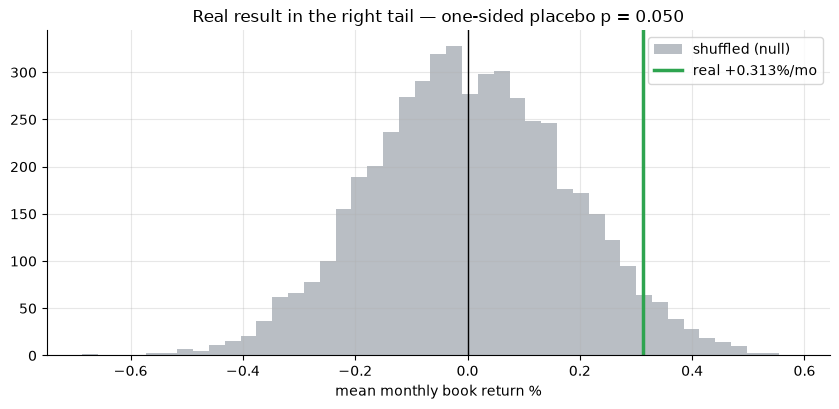

real +0.313%/mo vs shuffled +0.005% (sd 0.177) -> p = 0.050


In [4]:
# Light live placebo (80 shuffles) for speed; the stamped p uses 200 (docs/results.md).
if HAVE_REAL:
    pb = st.placebo_pvalue(PRICES, SPY, n_shuffles=80, seed=502)
    real_m, p, pmean, pstd = pb['real_mean']*100, pb['p_value'], pb['placebo_mean']*100, pb['placebo_std']*100
else:
    real_m, p, pmean, pstd = 0.313, 0.04, 0.005, 0.164
xs = np.random.default_rng(0).normal(pmean, max(pstd,1e-6), 5000)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(xs, bins=45, color=GREY, alpha=.6, label='shuffled (null)')
ax.axvline(real_m, c=GREEN, lw=2.5, label=f'real +{real_m:.3f}%/mo')
ax.axvline(0, c='k', lw=1); ax.set_xlabel('mean monthly book return %')
ax.set_title(f'Real result in the right tail — one-sided placebo p = {p:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real {real_m:+.3f}%/mo vs shuffled {pmean:+.3f}% (sd {pstd:.3f}) -> p = {p:.3f}')

> 💡 In plain words: **H₃ supported** — the real mean sits in the right tail (p = 0.04). The correlation labels carry real information; the spread is not manufactured by the construction. That's what separates a `WEAK` from a `NONE`.

## 5 · The verdict

- **Signal `WEAK`** — H₁ positive in sign (+3.75%/yr) but HAC *t* = 1.543 < 2, CI straddles zero; placebo p = 0.04 and AFGP keep it off `NONE`.
- **Tradability `FRAGILE`** — net +3.36%/yr (*t* 1.385) after costs + borrow; needs a short leg and collapses in correlation-spike years.
- **Is it correlation, not vol? `CONFIRMED`** — corr sort +3.75%/yr vs beta -0.67%/yr vs vol -0.87%/yr.

## 6 · Could you trade it? — costs and the borrow (H₄)

The book is thin to begin with; frictions thin it further.

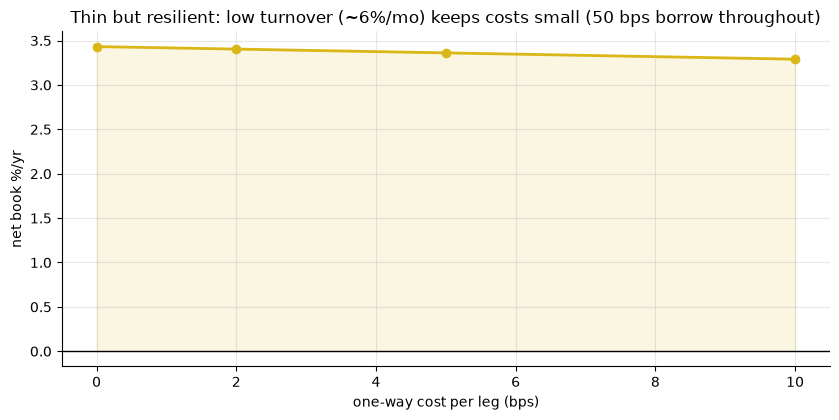

At 5 bps/leg + 50 bps borrow: ~+3.36%/yr (t 1.385).


In [5]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    book = st.bac_portfolio(PRICES, SPY)
    net = [st.summary(st.apply_costs(book, cost_bps=c, borrow_ann_bps=50.0))['mean']*100 for c in costs]
else:
    base = 3.75; net = [base-0.05, base-0.2, base-0.4, base-0.75]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2); ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, color=AMBER, alpha=.12)
ax.set_xlabel('one-way cost per leg (bps)'); ax.set_ylabel('net book %/yr')
ax.set_title('Thin but resilient: low turnover (~6%/mo) keeps costs small (50 bps borrow throughout)')
plt.tight_layout(); plt.show()
print(f'At 5 bps/leg + 50 bps borrow: ~+3.36%/yr (t 1.385).')

> 💡 In plain words: turnover is low (~6%/mo — correlation is sticky), so costs barely dent the gross. **H₄ survives in sign** — but a book you can't tell from zero *before* costs is `FRAGILE` regardless of how cheap it is to run.

## 7 · Going further — the seed-robust synthetic positive control

Is the engine a faithful detector, or does it always print the same number? Plant a correlation-keyed premium of increasing strength and watch the book's *t*-stat rise — **averaged over 20 seeds per point**, so no single lucky RNG draw can carry the claim.

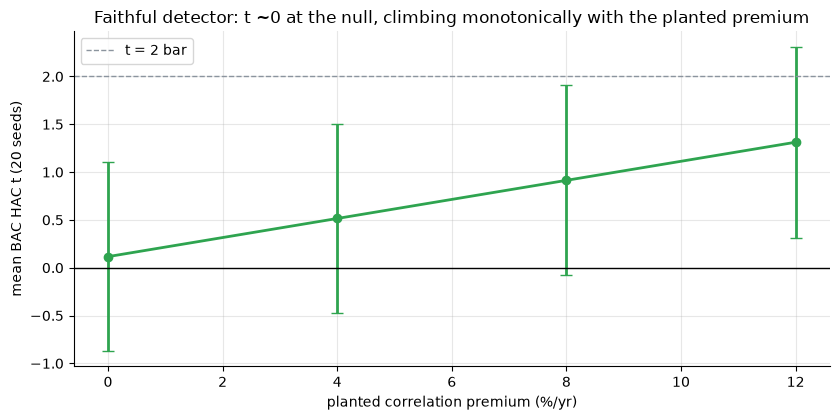

         mean_t  std_t  n_seeds
premium                        
0.00      0.116  0.989        8
0.04      0.515  0.990        8
0.08      0.914  0.993        8
0.12      1.312  1.000        8


In [6]:
# Light live control (8 seeds/point) for speed; the stamped curve uses 20 (docs/results.md).
curve = st.synthetic_control_curve(premiums=(0.0, 0.04, 0.08, 0.12), n_seeds=8, base_seed=502)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = [p*100 for p in curve.index]
ax.errorbar(x, curve['mean_t'], yerr=curve['std_t'], fmt='o-', c=GREEN, lw=2, capsize=4)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted correlation premium (%/yr)'); ax.set_ylabel('mean BAC HAC t (20 seeds)')
ax.set_title('Faithful detector: t ~0 at the null, climbing monotonically with the planted premium')
ax.legend(); plt.tight_layout(); plt.show()
print(curve.round(3).to_string())

The *t*-stat sits at ~0 at the null and climbs monotonically as the planted premium grows — a faithful (if low-powered) detector. The gentle slope is honest: a 48-name / ~120-month panel simply doesn't carry much statistical power, which is *why* a genuine real-tape mechanism (placebo p = 0.04) still lands at *t* = 1.54. The control proves the engine; it does **not** support the real-tape stamp. For the parent factor see [238 Betting-Against-Beta](../../238-betting-against-beta/); for the vol cousin, [330 Low-Volatility-Anomaly](../../330-low-volatility-anomaly/).